In [1]:
# Install if not already installed
import subprocess
subprocess.run(["pip", "install", "shap", "lime"], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shap
import lime
import lime.lime_tabular
import pickle, os, json, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score

print("SHAP version:", shap.__version__)
print("All explainability libraries loaded")

SHAP version: 0.51.0
All explainability libraries loaded


In [2]:
BASE   = r"C:\Users\User\Documents\StartupSucessPrediction\outputs\\"
MODELS = r"C:\Users\User\Documents\StartupSucessPrediction\models\\"
PLOTS  = r"C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\\"

os.makedirs(PLOTS, exist_ok=True)

# Load data
X_train = pd.read_csv(BASE + "X_train.csv")
X_test  = pd.read_csv(BASE + "X_test.csv")
y_train = pd.read_csv(BASE + "y_train.csv").squeeze()
y_test  = pd.read_csv(BASE + "y_test.csv").squeeze()

feature_names = list(X_train.columns)

# Load best classical model
with open(MODELS + "best_classical_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(MODELS + "best_model_name.txt", "r") as f:
    model_name = f.read().strip()

print(f" Loaded model   : {model_name}")
print(f" Features       : {len(feature_names)}")
print(f" Test samples   : {len(X_test)}")

 Loaded model   : Random Forest
 Features       : 42
 Test samples   : 191


In [10]:
print("⏳ Creating SHAP explainer (may take 30-60 seconds)...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Fix — handle all possible output shapes from different model types
if isinstance(shap_values, list):
    # Old sklearn format → list of 2 arrays [class0, class1]
    sv = np.array(shap_values[1])
elif hasattr(shap_values, 'values'):
    # New SHAP format → Explanation object
    sv = shap_values.values
    if sv.ndim == 3:
        sv = sv[:, :, 1]   # pick class 1 = Acquired
else:
    sv = np.array(shap_values)
    if sv.ndim == 3:
        sv = sv[:, :, 1]

# Final safety check
sv = np.array(sv, dtype=np.float64)

print(f"  SHAP values computed!")
print(f"   Shape  : {sv.shape}  ← should be (samples, features)")
print(f"   Example: first startup, top feature impact = {sv[0, np.argmax(np.abs(sv[0]))]:.4f}")

⏳ Creating SHAP explainer (may take 30-60 seconds)...
  SHAP values computed!
   Shape  : (191, 42)  ← should be (samples, features)
   Example: first startup, top feature impact = 0.0878


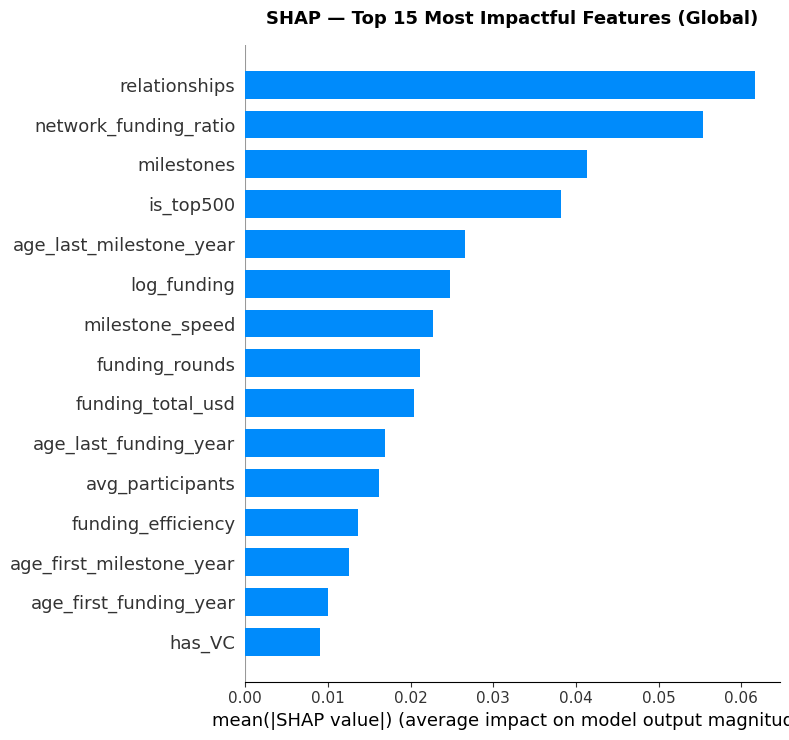

 Saved plot 23


In [11]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_test,
    plot_type="bar",
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP — Top 15 Most Impactful Features (Global)", 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PLOTS + "23_shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved plot 23")

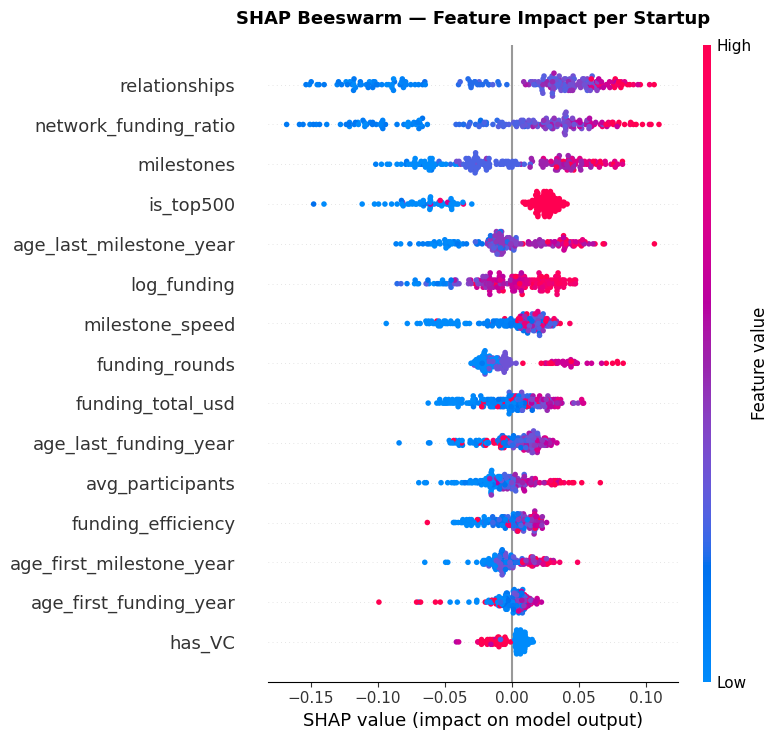

Saved plot 24


In [12]:
plt.figure(figsize=(11, 8))
shap.summary_plot(
    sv, X_test,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact per Startup",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PLOTS + "24_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot 24")

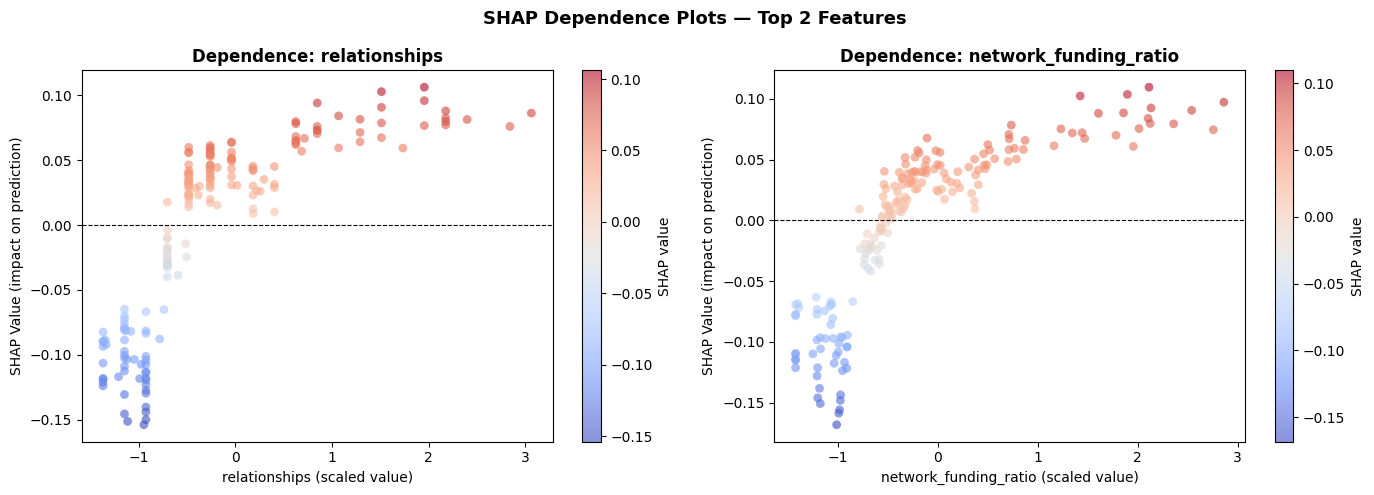

 Saved plot 25


In [13]:
# Auto-pick top 2 most important features
mean_shap     = np.abs(sv).mean(axis=0)
top2_idx      = np.argsort(mean_shap)[::-1][:2].tolist()   # ← .tolist() fixes the error
top2_features = [feature_names[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, top2_features):
    feat_idx       = feature_names.index(feat)
    shap_vals_feat = sv[:, feat_idx]
    feat_vals      = X_test.iloc[:, feat_idx].values        # ← .iloc fixes DataFrame indexing

    sc = ax.scatter(feat_vals, shap_vals_feat,
                    c=shap_vals_feat, cmap='coolwarm',
                    alpha=0.6, edgecolors='none', s=40)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f"{feat} (scaled value)", fontsize=10)
    ax.set_ylabel("SHAP Value (impact on prediction)", fontsize=10)
    ax.set_title(f"Dependence: {feat}", fontweight='bold')
    plt.colorbar(sc, ax=ax, label='SHAP value')

plt.suptitle("SHAP Dependence Plots — Top 2 Features",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + "25_shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved plot 25")

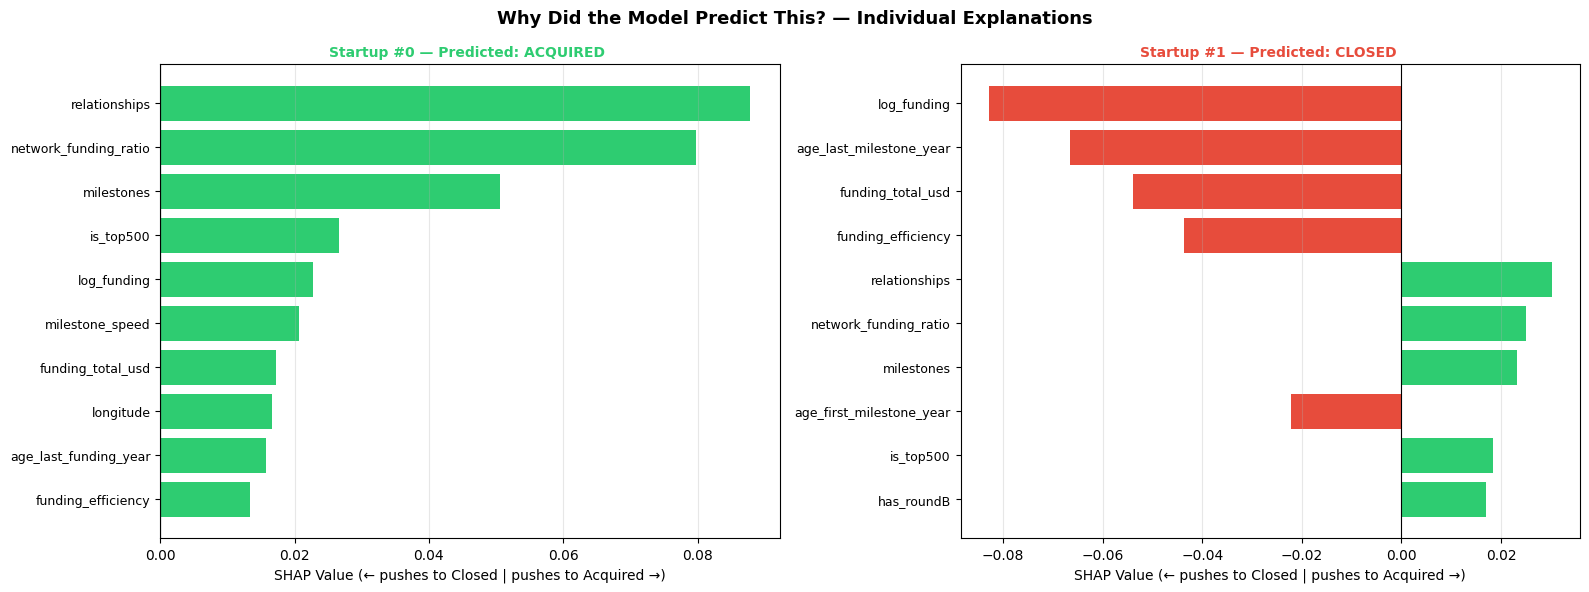

Saved plot 26


In [14]:
# Pick one correctly predicted success and one correctly predicted failure
y_pred    = model.predict(X_test)
correct   = np.where(y_pred == y_test.values)[0]

# Find one success and one failure from correct predictions
success_idx = correct[y_test.values[correct] == 1][0]
failure_idx = correct[y_test.values[correct] == 0][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
titles    = [f"Startup #{success_idx} — Predicted: ACQUIRED ",
             f"Startup #{failure_idx} — Predicted: CLOSED "]
indices   = [success_idx, failure_idx]
colors_wf = ['#2ecc71', '#e74c3c']

for ax, idx, title, color in zip(axes, indices, titles, colors_wf):
    shap_vals_single = sv[idx]
    top_n  = 10
    sorted_idx   = np.argsort(np.abs(shap_vals_single))[::-1][:top_n]
    sorted_vals  = shap_vals_single[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]

    bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in sorted_vals]
    bars = ax.barh(range(top_n), sorted_vals[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(sorted_names[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("SHAP Value (← pushes to Closed | pushes to Acquired →)")
    ax.set_title(title, fontweight='bold', color=color, fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle("Why Did the Model Predict This? — Individual Explanations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + "26_shap_waterfall_individual.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot 26")

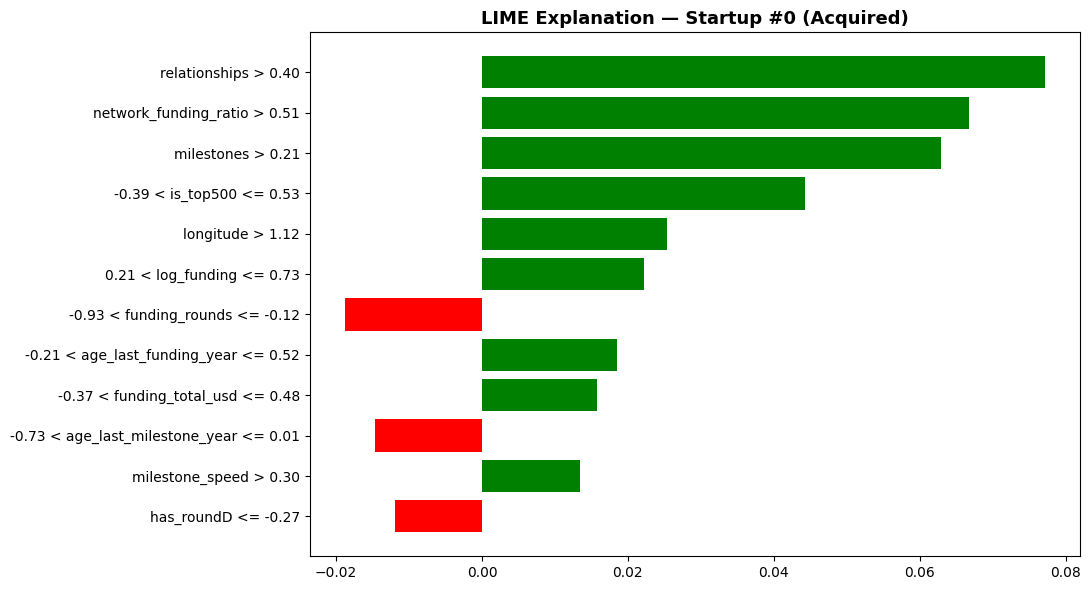

 Saved plot 27


In [15]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = feature_names,
    class_names    = ["Closed", "Acquired"],
    mode           = "classification",
    random_state   = 42
)

# Explain the same success startup we used above
lime_exp = lime_explainer.explain_instance(
    data_row       = X_test.values[success_idx],
    predict_fn     = model.predict_proba,
    num_features   = 12
)

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(11, 6)
plt.title(f"LIME Explanation — Startup #{success_idx} (Acquired)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + "27_lime_explanation.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved plot 27")

In [16]:
OUT = r"C:\Users\User\Documents\StartupSucessPrediction\outputs\\"

mean_shap_vals = np.abs(sv).mean(axis=0)
shap_summary   = pd.DataFrame({
    "Feature":         feature_names,
    "Mean_SHAP":       mean_shap_vals,
    "Positive_Impact": (sv > 0).mean(axis=0),   # % of startups where feature helped
    "Negative_Impact": (sv < 0).mean(axis=0)    # % of startups where feature hurt
}).sort_values("Mean_SHAP", ascending=False)

shap_summary.to_csv(OUT + "shap_feature_summary.csv", index=False)

print(" Saved: outputs/shap_feature_summary.csv")
print("\n TOP 10 MOST IMPACTFUL FEATURES:")
print("=" * 50)
print(shap_summary[["Feature","Mean_SHAP"]].head(10).to_string(index=False))

 Saved: outputs/shap_feature_summary.csv

 TOP 10 MOST IMPACTFUL FEATURES:
                Feature  Mean_SHAP
          relationships   0.061584
  network_funding_ratio   0.055362
             milestones   0.041282
              is_top500   0.038134
age_last_milestone_year   0.026609
            log_funding   0.024794
        milestone_speed   0.022672
         funding_rounds   0.021171
      funding_total_usd   0.020383
  age_last_funding_year   0.016914
